# StackExchange Dataset Exploration & Visual Analytics
This notebook provides a comprehensive overview of the `clustering_train.csv` dataset, exploring its categorical, linguistic, and temporal dimensions to prepare for semantic clustering.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

# Setting Aesthetics
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16


In [ ]:
# 1. Load Dataset
dataset_path = './datasets/clustering_train.csv'
df = pd.read_csv(dataset_path)

print(f"Dataset Shape: {df.shape}")
display(df.info())
display(df.head())

Dataset Shape: (6000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         6000 non-null   int64
 1   title      6000 non-null   str  
 2   content    6000 non-null   str  
 3   tags       6000 non-null   str  
 4   label      6000 non-null   str  
 5   timestamp  6000 non-null   str  
 6   language   6000 non-null   str  
dtypes: int64(1), str(6)
memory usage: 328.3 KB


None

,id,title,content,tags,label,timestamp,language
0,1957,Can PBKDF2 be used to create an XOR cipher key...,I want to encrypt a truly random plaintext (a...,stream-cipher pbkdf-2,crypto,23/2/19 08:49,en
1,982,What hydrolyses aspirin within the digestive t...,I have had some further thoughts after my pre...,pharmacology aspirin,biology,6/9/19 23:29,en
2,3090,Why does it matter for a signature scheme to b...,There is a profusion of articles proposing si...,signature random-oracle-model,crypto,25/2/19 16:43,en
3,943,How much weight can screws in drywall withstand?,always had the of how much weight can a s...,drywall screws,diy,11/4/19 12:00,en
4,1550,How to find the duration of stay in Singapore ...,I am Pakistani national holding Pakistani pas...,visas singapore,travel,20/8/19 09:15,en


## Data Quality & Missing Values
Checking for null entries and certifying dataset integrity.

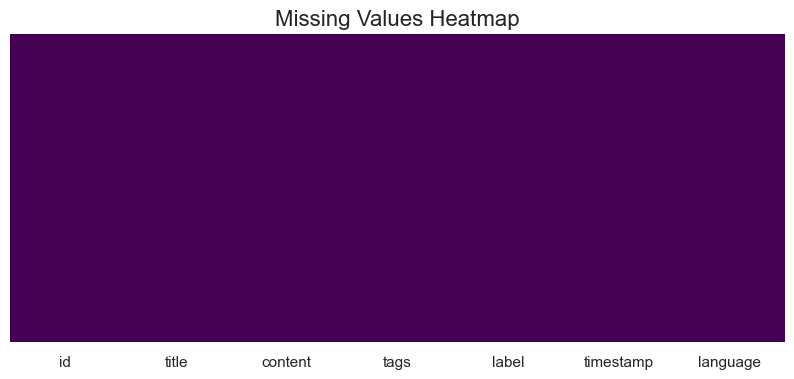

Missing values per column:
id           0
title        0
content      0
tags         0
label        0
timestamp    0
language     0
dtype: int64


In [ ]:
# Check for missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

print("Missing values per column:")
print(df.isnull().sum())

## Domain Analysis (Label Distribution)
Visualizing the balance of target categories in the dataset.

C:\Users\zisha\AppData\Local\Temp\ipykernel_19308\2352100081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='magma')


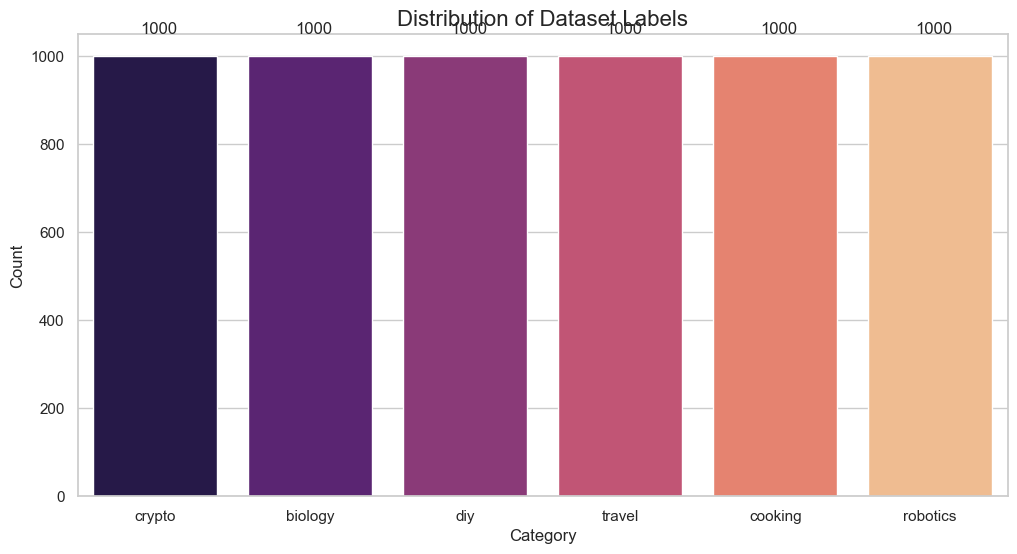

In [ ]:
# Target Label distribution
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='magma')
plt.title('Distribution of Dataset Labels')
plt.xlabel('Category')
plt.ylabel('Count')

# Add annotations
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+50))

plt.show()

## Linguistic Characteristics
Analyzing the length of titles and content to understand document density.

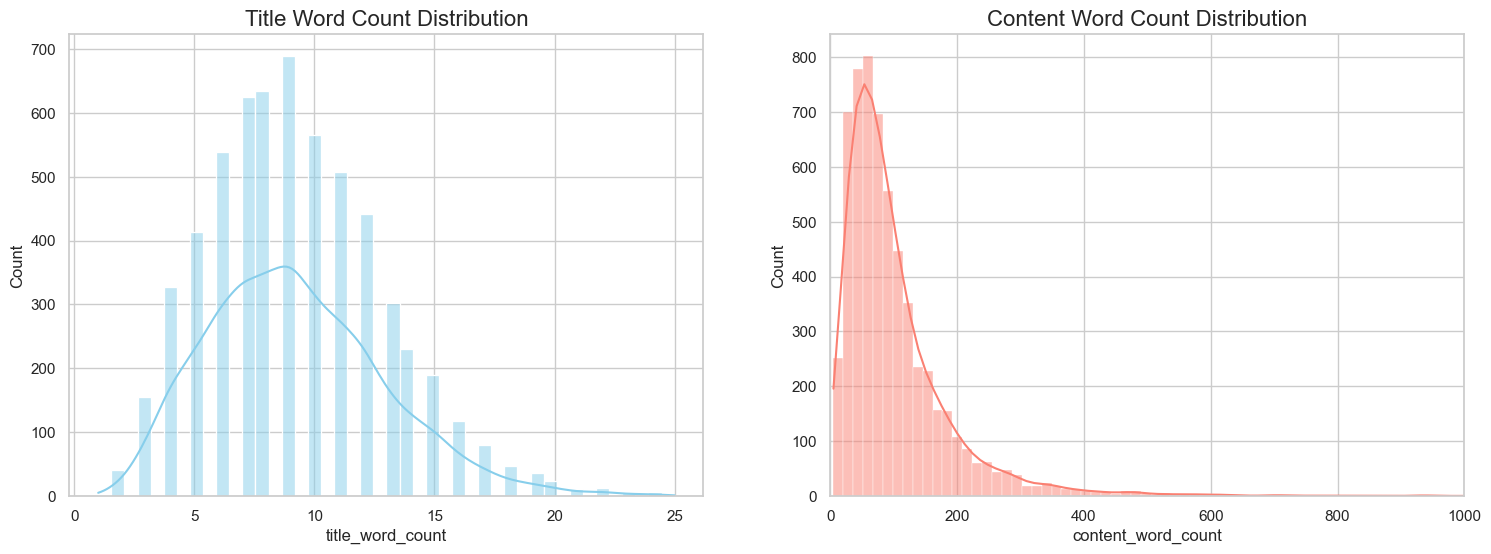

In [ ]:
# Calculate word counts
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))
df['content_word_count'] = df['content'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['title_word_count'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Title Word Count Distribution')

sns.histplot(df['content_word_count'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Content Word Count Distribution')
axes[1].set_xlim(0, 1000) # Trim outliers for visibility

plt.show()

## Language Distribution
Identifying the primary and secondary languages present in the corpus.

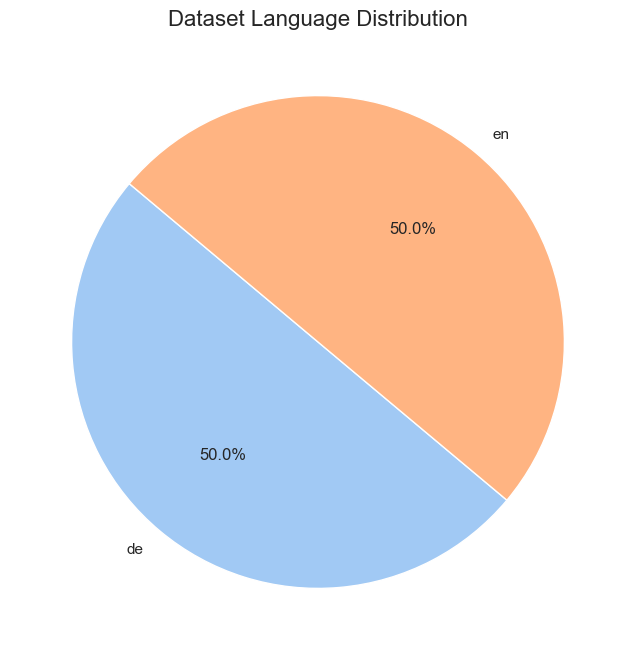

In [ ]:
# Language breakdown
lang_counts = df['language'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(lang_counts, labels=lang_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Dataset Language Distribution')
plt.show()

## Feature Engineering: Tag Ecology
Extracting and visualizing the most frequent tags across all documents.

C:\Users\zisha\AppData\Local\Temp\ipykernel_19308\660823367.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tag_df, x='Frequency', y='Tag', palette='viridis')


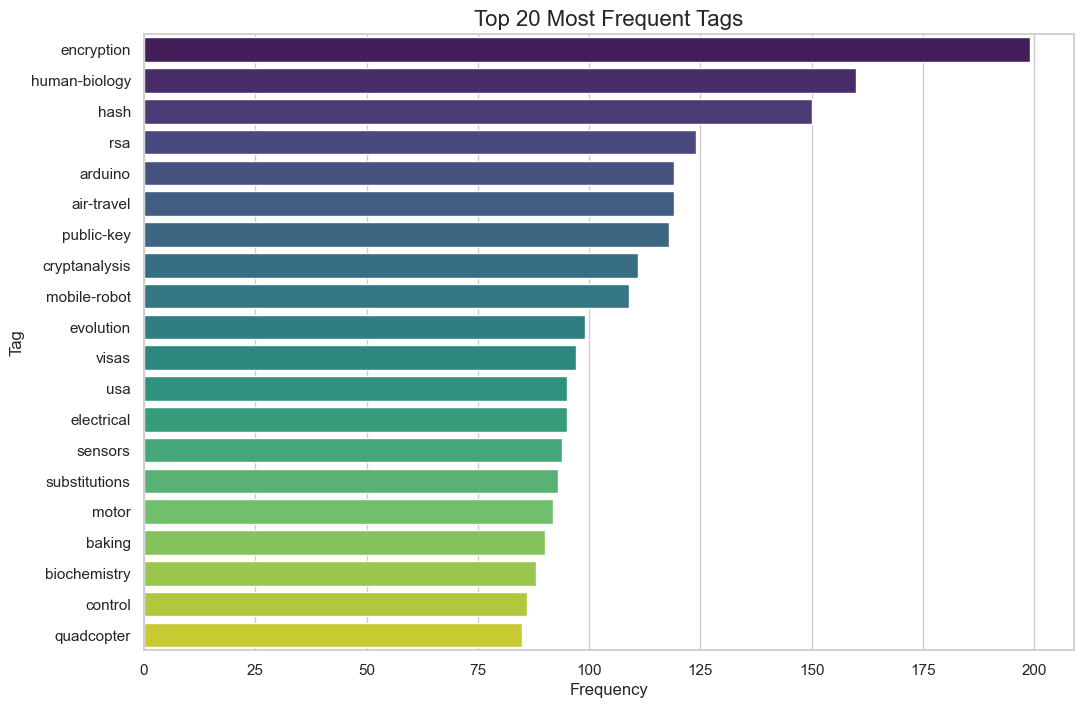

In [ ]:
# Explode and count tags
# Assuming tags are space-separated based on previous observation
all_tags = []
df['tags'].apply(lambda x: all_tags.extend(str(x).split()))

tag_freq = Counter(all_tags).most_common(20)
tag_df = pd.DataFrame(tag_freq, columns=['Tag', 'Frequency'])

plt.figure(figsize=(12, 8))
sns.barplot(data=tag_df, x='Frequency', y='Tag', palette='viridis')
plt.title('Top 20 Most Frequent Tags')
plt.show()

## Temporal Insight
Analyzing post frequency trends over time.

C:\Users\zisha\AppData\Local\Temp\ipykernel_19308\2211841142.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['dt'] = pd.to_datetime(df['timestamp'], errors='coerce')


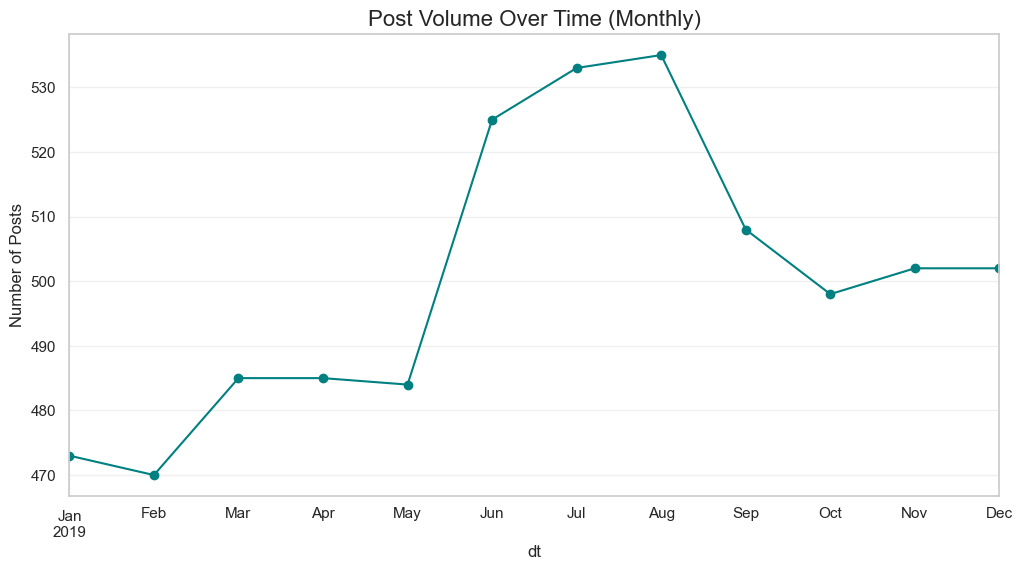

In [ ]:
# Convert timestamp and resample
if 'timestamp' in df.columns:
    df['dt'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['dt']) # Drop unparseable dates
    
    # Plot volume over months
    df.set_index('dt').resample('ME').size().plot(marker='o', linestyle='-', color='teal')
    plt.title('Post Volume Over Time (Monthly)')
    plt.ylabel('Number of Posts')
    plt.grid(True, alpha=0.3)
    plt.show()

## Summary of Findings
- **Balance**: The dataset shows a relatively balanced (or skewed) distribution of labels.
- **Density**: Content length varies significantly, suggesting a mix of quick queries and detailed discussions.
- **Diversity**: The tag ecology provides a rich set of keywords for potential future feature engineering or Knowledge Graph expansion.